## Indicador de rendimiento estudiantil

### Ciclo de vida de un proyecto de aprendizaje automático

* Comprensión del problema
* Recopilación de datos
* Verificaciones de datos
* Análisis exploratorio de datos
* Preprocesamiento de datos
* Entrenamiento del modelo
* Selección del mejor modelo

## 1) Planteamiento del problema:

### Este proyecto analiza cómo el rendimiento estudiantil (puntuaciones en las pruebas) se ve afectado por otras variables como el género, la etnia, el nivel educativo de los padres, el almuerzo y el curso de preparacion para las pruebas.

## 2) Recopilacion de datos:

### Fuente del conjunto de datos: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977.
Los datos constan de 8 columnas y 1000 filas

## 2.1 Importacion de datos y paquetes necesarios

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Importo los datos csv como un DataFrame de Pandas.

In [2]:
df = pd.read_csv('./data/stud.csv')

### Mostrar los 5 mejores récords

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Shape del dataset

In [4]:
df.shape

(1000, 8)

### 2.2 Información del conjunto de datos

* Género: Sexo del estudiante (masculino/femenino).
* Raza/etnia: Etnia del estudiante (grupo A, B, C, D, E).
* Nivel educativo de los padres: nivel educativo final de los padres (licenciatura, estudios universitarios incompletos, maestria, titulo tecnico superior, bachillerato).
* Almuerzo: Si almorzaron antes del examen (estándar o gratuito/reducido).
* Curso de preparación para el examen: Si lo completaron o no antes del examen.
* Puntuación en matemáticas.
* Puntuacion de lectura.
* Puntuacion de escritura.

### 3. Verifiacciones de datos

* Verificar valores faltantes.
* Verificar duplicados.
* Verificar el tipo de los datos.
* Verificar el número de valores únicos de cada columna.
* Verificar las estadisticas del conjunto de datos.
* Verificar las distintas categorias presentes en las diferentes columnas categóricas.

### 3.1 Verificar valores faltantes

In [5]:
valores_faltantes = df.isna().sum()

print(valores_faltantes)

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


No hay valores faltantes en el conjunto de datos.

### 3.2 Verificar duplicados

In [6]:
valores_duplicados = df.duplicated().sum()

print(f'Cantidad de valores duplicados: {valores_duplicados}')

Cantidad de valores duplicados: 0


### 3.3 Verificación de los tipos de datos

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Comprobando el número de valores únicos de cada columna.

In [8]:
valores_unicos = df.nunique()

print(valores_unicos)

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64


### 3.5 Comprobar las estadísticas del conjunto de datos

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Analisis: 
* Según la descripcion anterior de los datos numéricos, todas las medias son muy similares entre so, entre 66 y 68,05;
* Todas las desviaciones estándar tambien son similares, entre 14,6 y15,19;
* Si bien la puntuación minima en matemáticas es 0, en escritura la minima es mucho mayor (10) y en lectura es aún mayor (17)

## 3. Tranformacion de las columnas a español

In [10]:
df = df.rename(columns={
    "gender": "genero",
    "race_ethnicity": "grupo_etnico",
    "parental_level_of_education": "nivel_educacion_padres",
    "lunch": "almuerzo",
    "test_preparation_course": "curso_preparacion",
    "math_score": "nota_matematica",
    "reading_score": "nota_lectura",
    "writing_score": "nota_escritura"
})

# genero
df["genero"] = df["genero"].map({
    "female": "femenino",
    "male": "masculino"
})

# grupo étnico (opcional, podés dejarlo igual si querés)
df["grupo_etnico"] = df["grupo_etnico"].str.replace("group ", "grupo ")

# nivel educación padres
df["nivel_educacion_padres"] = df["nivel_educacion_padres"].map({
    "bachelor's degree": "licenciatura",
    "master's degree": "maestria",
    "associate's degree": "tecnicatura",
    "some college": "algo de universidad",
    "high school": "secundaria",
    "some high school": "secundaria incompleta"
})

# almuerzo
df["almuerzo"] = df["almuerzo"].map({
    "standard": "estandar",
    "free/reduced": "gratuito/reducido"
})

# curso preparación
df["curso_preparacion"] = df["curso_preparacion"].map({
    "none": "ninguno",
    "completed": "completado"
})

## 3.7 Exploracion de datos

In [11]:
df.head()

,genero,grupo_etnico,nivel_educacion_padres,almuerzo,curso_preparacion,nota_matematica,nota_lectura,nota_escritura
0,femenino,grupo B,licenciatura,estandar,ninguno,72,72,74
1,femenino,grupo C,algo de universidad,estandar,completado,69,90,88
2,femenino,grupo B,maestria,estandar,ninguno,90,95,93
3,masculino,grupo A,tecnicatura,gratuito/reducido,ninguno,47,57,44
4,masculino,grupo C,algo de universidad,estandar,ninguno,76,78,75


In [12]:
print('Categorias en la variable "genero":', end='')

print(df['genero'].unique())

print('Categorias en la variable "grupo_etnico:', end='')
print(df['grupo_etnico'].unique())

print('Categorias en la variable "nivel aducativo de los padres:', end='')
print(df['nivel_educacion_padres'].unique())

print('Categorias en la variable "almuerzo":', end='')
print(df['almuerzo'].unique())

Categorias en la variable "genero":['femenino' 'masculino']
Categorias en la variable "grupo_etnico:['grupo B' 'grupo C' 'grupo A' 'grupo D' 'grupo E']
Categorias en la variable "nivel aducativo de los padres:['licenciatura' 'algo de universidad' 'maestria' 'tecnicatura'
 'secundaria' 'secundaria incompleta']
Categorias en la variable "almuerzo":['estandar' 'gratuito/reducido']


In [13]:
# Definir columnas numéricas y categóricas
caracteristicas_numericas = [car for car in df.columns if df[car].dtype != 'O']
caracteristicas_categoricas = [car for car in df.columns if df[car].dtype == 'O']

print('Tenemos {} caracteristicas numericas {}'.format(len(caracteristicas_numericas), caracteristicas_numericas))
print('\nTenemos {} caracteristicas categoricas {}'.format(len(caracteristicas_categoricas), caracteristicas_categoricas))

Tenemos 3 caracteristicas numericas ['nota_matematica', 'nota_lectura', 'nota_escritura']

Tenemos 5 caracteristicas categoricas ['genero', 'grupo_etnico', 'nivel_educacion_padres', 'almuerzo', 'curso_preparacion']


In [14]:
df.head(2)

,genero,grupo_etnico,nivel_educacion_padres,almuerzo,curso_preparacion,nota_matematica,nota_lectura,nota_escritura
0,femenino,grupo B,licenciatura,estandar,ninguno,72,72,74
1,femenino,grupo C,algo de universidad,estandar,completado,69,90,88


## 3.8 Agregar columnas para "Puntuación total y "Promedio".

In [15]:
df['puntuacion_total'] = df['nota_matematica'] + df['nota_lectura'] + df['nota_escritura']
df['promedio'] = df['puntuacion_total'] / 3

df.head()

,genero,grupo_etnico,nivel_educacion_padres,almuerzo,curso_preparacion,nota_matematica,nota_lectura,nota_escritura,puntuacion_total,promedio
0,femenino,grupo B,licenciatura,estandar,ninguno,72,72,74,218,72.666667
1,femenino,grupo C,algo de universidad,estandar,completado,69,90,88,247,82.333333
2,femenino,grupo B,maestria,estandar,ninguno,90,95,93,278,92.666667
3,masculino,grupo A,tecnicatura,gratuito/reducido,ninguno,47,57,44,148,49.333333
4,masculino,grupo C,algo de universidad,estandar,ninguno,76,78,75,229,76.333333


In [16]:
lectura_maxima = df[df['nota_lectura'] == 100]['promedio'].count()
matem_maxima = df[df['nota_matematica'] == 100]['promedio'].count()
escritura_max = df[df['nota_escritura'] == 100]['promedio'].count()

print(f'Numeros de estudiante con la calificación maxima en matematicas: {matem_maxima}')
print(f'Números de estudiantes con la calificaciión maxima en lectura: {lectura_maxima}')
print(f'Número de estudiantes con la calificación maxima en escritura: {escritura_max}')

Numeros de estudiante con la calificación maxima en matematicas: 7
Números de estudiantes con la calificaciión maxima en lectura: 17
Número de estudiantes con la calificación maxima en escritura: 14


In [17]:
lectura_menos_20 = df[df['nota_lectura'] <= 20]['promedio'].count()
escritura_menos_20 = df[df['nota_escritura'] <= 20]['promedio'].count()
matematica_menos_20 = df[df['nota_matematica'] <= 20]['promedio'].count()

print(f'Número de estudiantes con menos de 20 puntos en Matematicas: {matematica_menos_20}')
print(f'Número de estudiantes con menos de 20 puntos en Escritura: {escritura_menos_20}')
print(f'Número de estudiantes con menos de 20 puntos en Lectura: {lectura_menos_20}')

Número de estudiantes con menos de 20 puntos en Matematicas: 4
Número de estudiantes con menos de 20 puntos en Escritura: 3
Número de estudiantes con menos de 20 puntos en Lectura: 1


Análisis: Según los valores anteriores, los estudiantes obtuvieron los peores resultados en Matemáticas. El mejor desempeño se registró en la seccion de Lectura

## 4 Exploración de datos (Visualización)

### 4.1 Visualizar la distribución de la puntuación promedio para extraer conclusiones.

* Histograma.
* Función de distribución del núcleo (KDE)

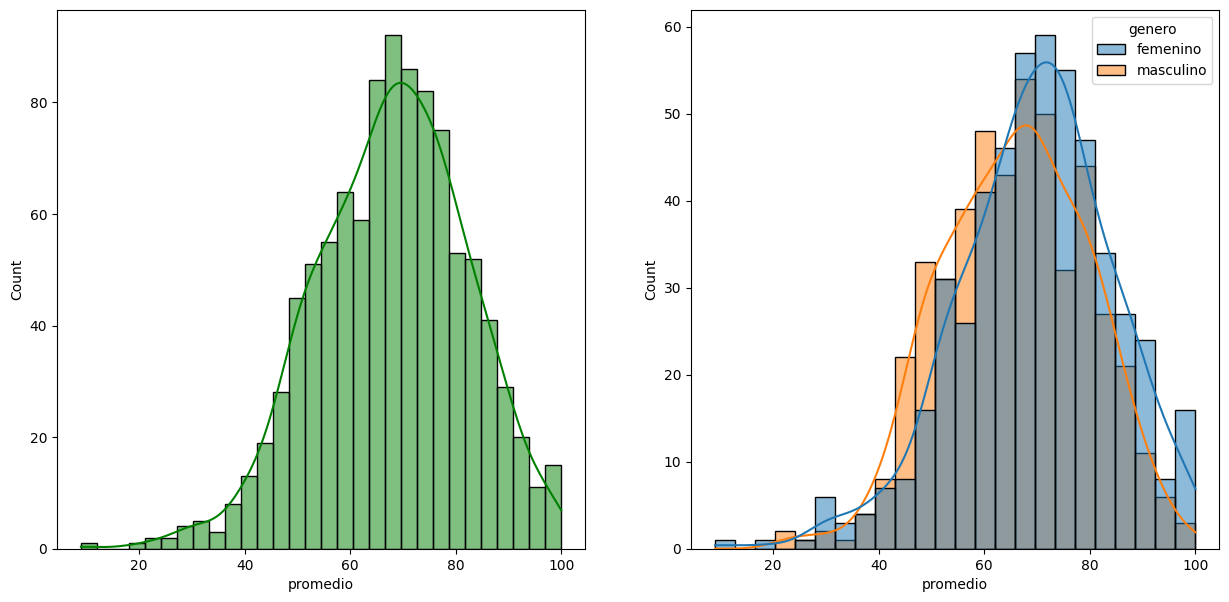

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data = df, x='promedio', bins=30, kde= True, color = 'g')
plt.subplot(122)
sns.histplot(data=df, x='promedio', kde=True, hue='genero')
plt.show()

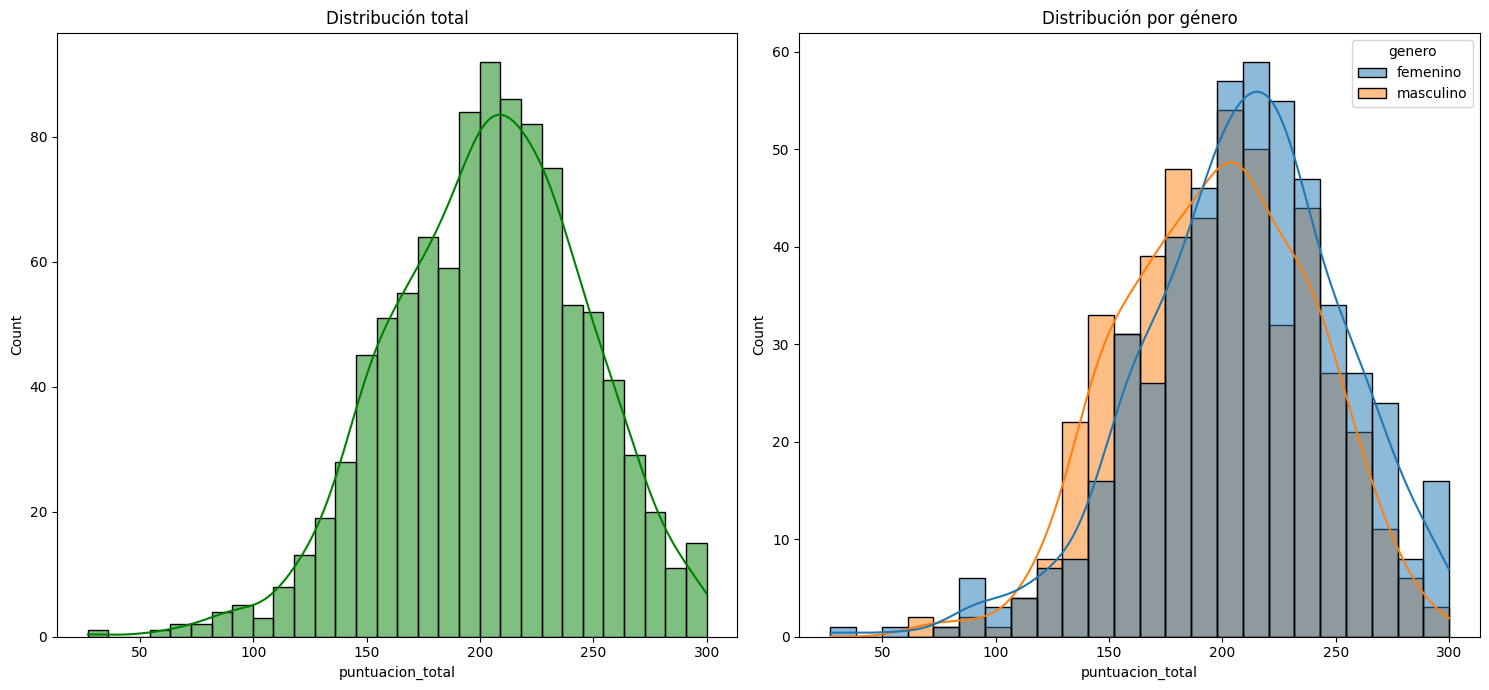

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=df, x='puntuacion_total', bins=30, kde=True, color='g', ax=axs[0])
axs[0].set_title('Distribución total')

sns.histplot(data=df, x='puntuacion_total', kde=True, hue='genero', ax=axs[1])
axs[1].set_title('Distribución por género')

plt.tight_layout()
plt.show()

Observaciones: Las estudiantes tienden a tener un mejor rendimiento que los estudiantes varones

In [20]:
df.head(2)

,genero,grupo_etnico,nivel_educacion_padres,almuerzo,curso_preparacion,nota_matematica,nota_lectura,nota_escritura,puntuacion_total,promedio
0,femenino,grupo B,licenciatura,estandar,ninguno,72,72,74,218,72.666667
1,femenino,grupo C,algo de universidad,estandar,completado,69,90,88,247,82.333333


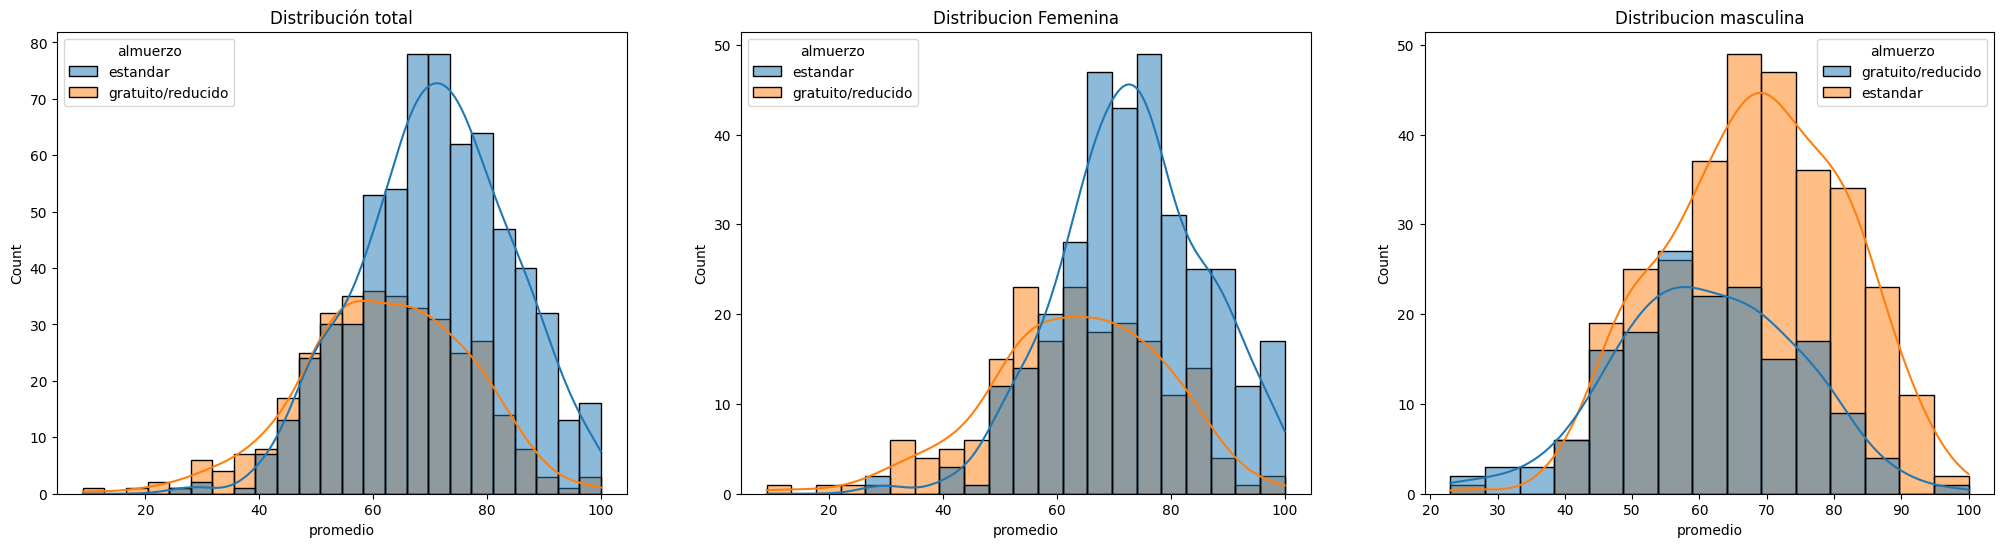

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data= df, x='promedio', kde=True, hue= 'almuerzo', ax=axs[0])
axs[0].set_title('Distribución total')

sns.histplot(data=df[df.genero == 'femenino'], x='promedio', kde=True, hue='almuerzo', ax=axs[1])
axs[1].set_title('Distribucion Femenina')

sns.histplot(data= df[df.genero == 'masculino'], x='promedio', kde=True, hue='almuerzo', ax=axs[2])
axs[2].set_title('Distribucion masculina')

plt.show()

Informacion:
* Un almuerzo regular ayuda a obtener buenos resultados en los exámenes.
* Un almuerzo regular ayda a obtener buenos resultados en los exámenes, tanto para hombres como para mujeres.

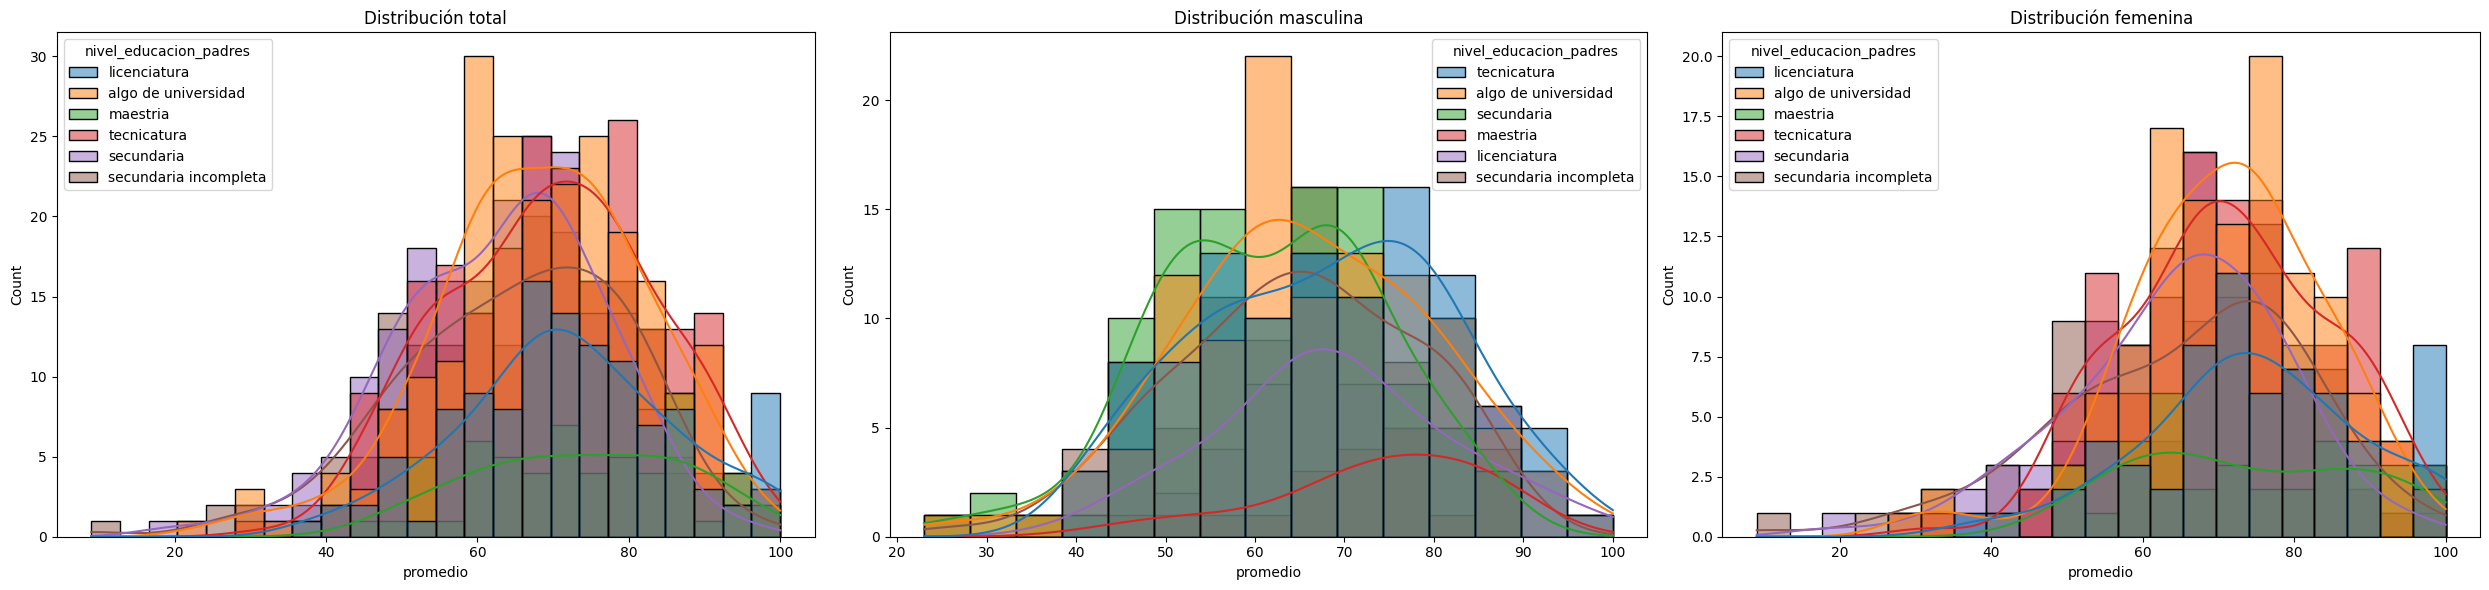

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df,x='promedio',kde=True,hue='nivel_educacion_padres',ax=axs[0])
axs[0].set_title('Distribución total')

sns.histplot(data=df[df.genero == 'masculino'],x='promedio',kde=True,hue='nivel_educacion_padres',ax=axs[1])
axs[1].set_title('Distribución masculina')

sns.histplot(data=df[df.genero == 'femenino'],x='promedio',kde=True,hue='nivel_educacion_padres',ax=axs[2])
axs[2].set_title('Distribución femenina')

plt.tight_layout()
plt.show()

Conclusiones:

* En general, la educación de los padres no influye en el rendimiento académico de los estudiantes.
* El segundo gráfico muestra que los hivos varones cuyos padres tienen un titulo de asociado o maestria tienden a obtener mejores resultados en los exámenes.
* El tercer gráfico se observa que la eduucación de los padres no tiene ningún efecto en las estudiantes.

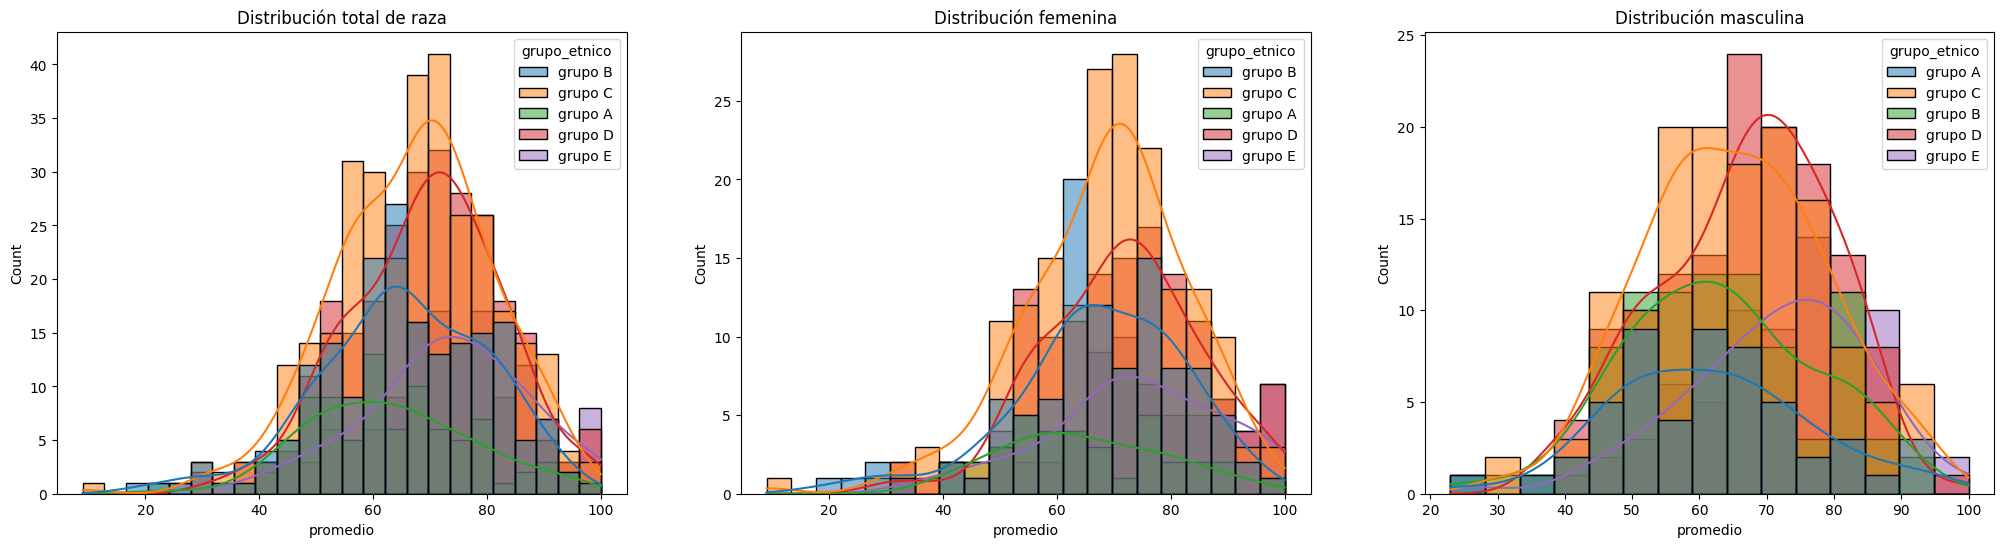

In [23]:
fig, axs = plt.subplots(1, 3,figsize=(25, 6))

sns.histplot(data= df, x='promedio', kde= True, hue= 'grupo_etnico', ax=axs[0])
axs[0].set_title('Distribución total de raza')

sns.histplot(df[df.genero == 'femenino'], x='promedio', kde= True, hue='grupo_etnico', ax=axs[1])
axs[1].set_title('Distribución femenina')

sns.histplot(df[df.genero == 'masculino'], x='promedio', kde= True, hue='grupo_etnico', ax=axs[2])
axs[2].set_title('Distribución masculina')

plt.show()


Análisis:
* Los estudiantes de los grupos A y B tienden a obtener malos resultados en los examenes.
* Los estudiantes de los grupos A y B tienden a obtener malos resultados en los exámenes independientemente de su género.

## 4.2 Puntuación máxima de los estudiantes en las tres asignaturas

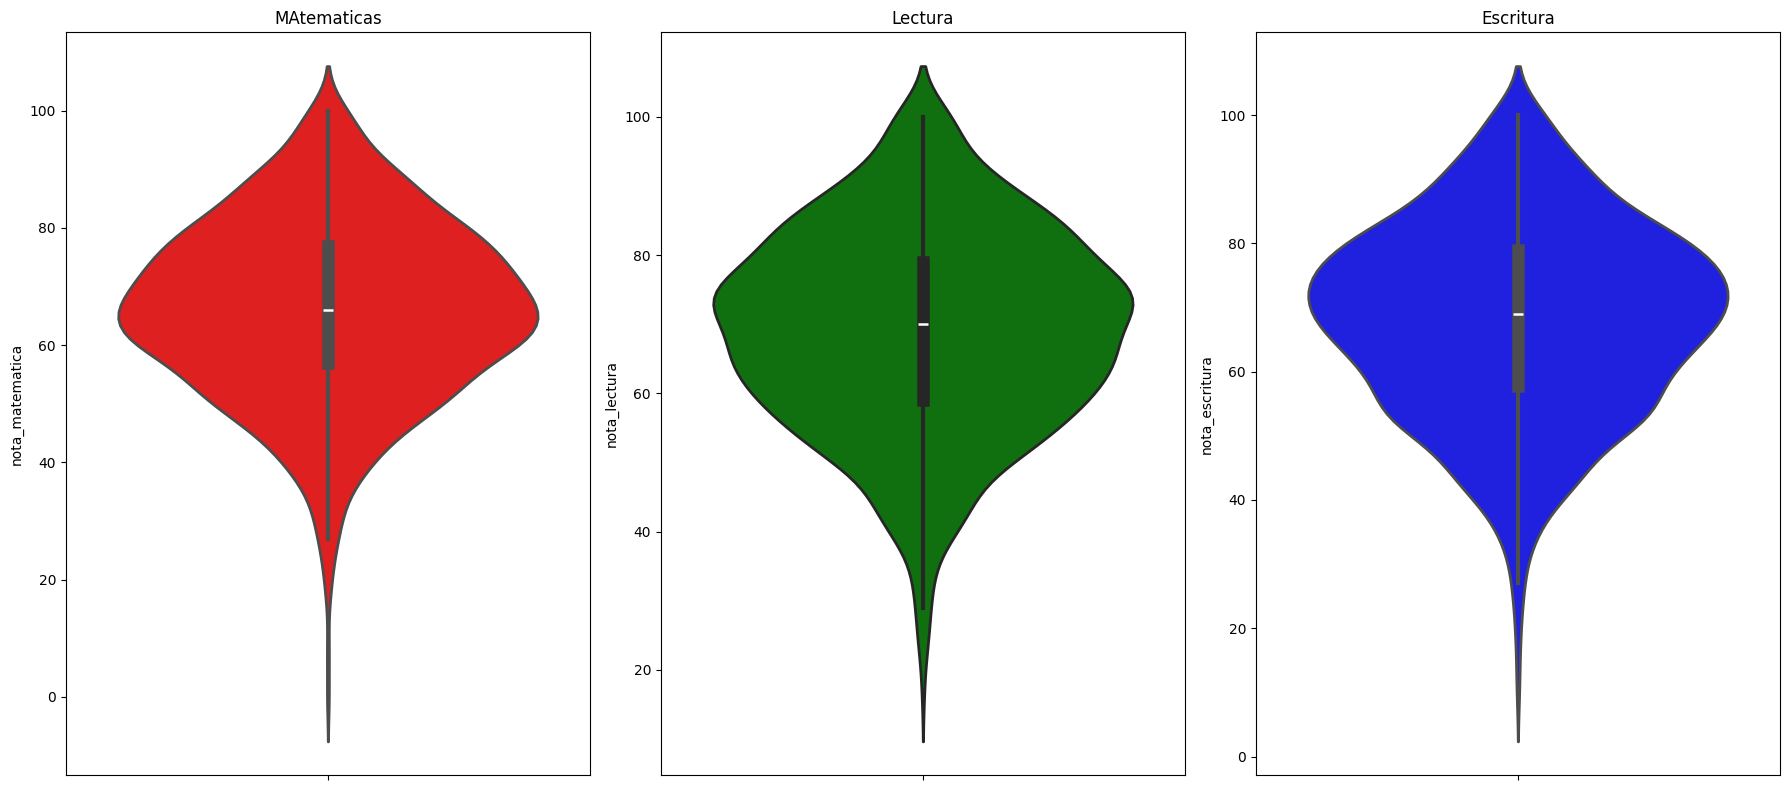

In [24]:
fig, axs= plt.subplots(1, 3, figsize=(18, 8))

sns.violinplot(y='nota_matematica', data=df, color='red', linewidth=2, ax=axs[0])
axs[0].set_title('MAtematicas')

sns.violinplot(y='nota_lectura', data= df, color='green', linewidth=2, ax=axs[1])
axs[1].set_title('Lectura')

sns.violinplot(y='nota_escritura', data=df, color='blue', linewidth=2, ax=axs[2])
axs[2].set_title('Escritura')

plt.tight_layout()
plt.show()

Anáñosos de los gráficos:

Se observa claramente que la mayoria de los estudiantes obtienen puntuaciones entre 60 y 80 en matemáticas, mientras que en lectura y escritura la mayoria obtiene puntuaciones entre 50 y 80

## 4.3 Anáñisis multivariado mediante gráficos circulares

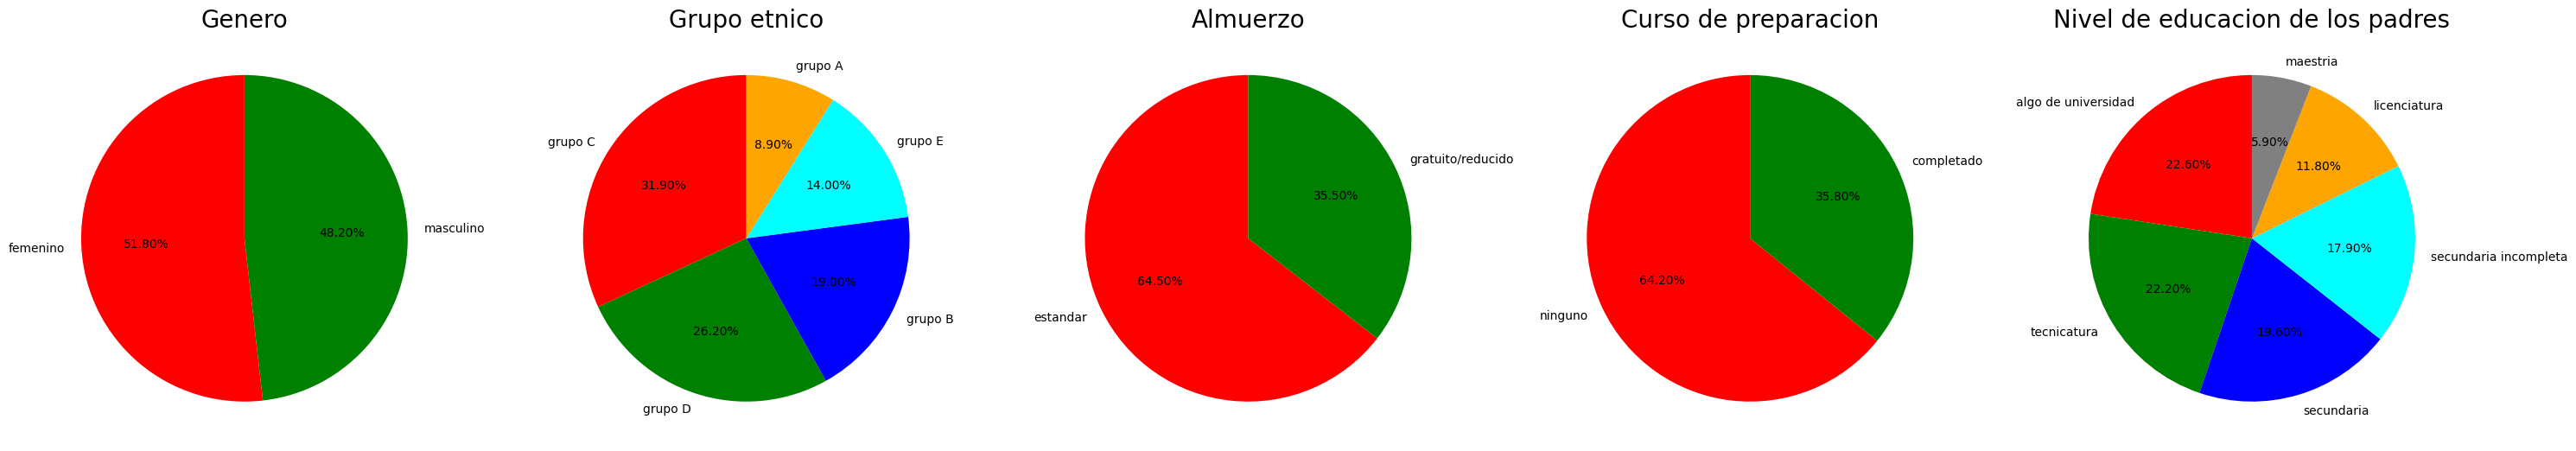

In [25]:
import matplotlib.pyplot as plt

# Configuración general de la figura
plt.rcParams['figure.figsize'] = (30, 12)
colors_palette = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']

# Definimos los datos de las columnas que queremos graficar
# Esto permite agregar o quitar gráficos fácilmente
columnas_interes = [
    ('genero', 'Genero'),
    ('grupo_etnico', 'Grupo etnico'),
    ('almuerzo', 'Almuerzo'),
    ('curso_preparacion', 'Curso de preparacion'),
    ('nivel_educacion_padres', 'Nivel de educacion de los padres')
]

# Creamos los subplots dinámicamente
for i, (col, titulo) in enumerate(columnas_interes, 1):
    plt.subplot(1, 5, i)
    
    # Obtención de datos
    datos_col = df[col].value_counts()
    
    # Graficado
    plt.pie(
        datos_col, 
        colors=colors_palette, 
        labels=datos_col.index, # Usamos los índices del DF para evitar errores manuales
        autopct='%.2f%%',       # Corregido el formato del porcentaje
        startangle=90           # Mejora la estética visual inicial
    )
    
    plt.title(titulo, fontsize=20)
    plt.axis('off')

# Ajuste automático para evitar que los títulos se solapen
plt.tight_layout()
plt.show()

Observacion:
* El número de estudiantes masculinos y femeninos es casi igual.
* El grupo C es el más nueroso.
* El número de estudiantes que reciban el almuerzo estándar es mayor.
* El número de estudiantes que no se han inscrito en ningún curso de preparación para exámenes es mayor.
* El número de estudiantes cuyos padres tienen estudios universitarios incompletos es mayor, seguido de cerca por aquellos con titulo de asociado.

## 4.4 Visualización por caracteristicas

### 4.4.1 Columna genero

* ¿Cómo es la distribución por género?
* ¿Tiene el género algún impacto en el rendimiento estudiantil?

### ANÁLISIS UNIVARIADO (¿Cómo es la distribución por género?)

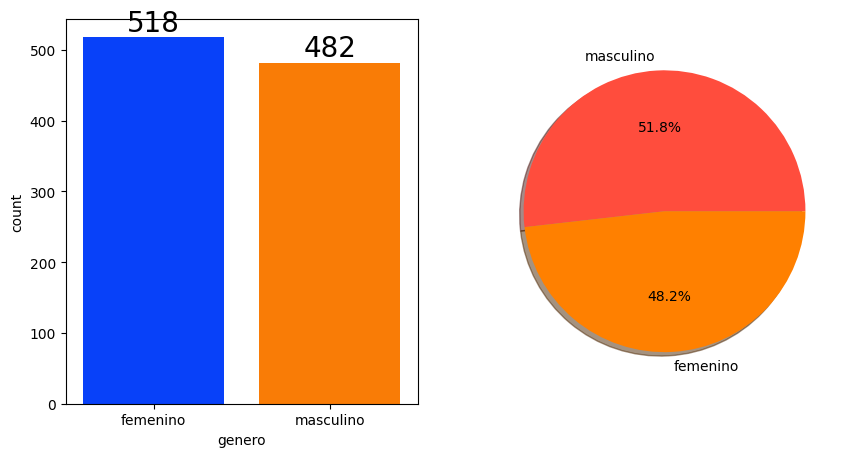

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x=df['genero'], data= df, palette='bright', ax=axs[0], saturation=0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=20)

axs[1].pie(x=df['genero'].value_counts()
    , labels=['masculino', 'femenino']
    , autopct='%1.1f%%',
    shadow=True, 
    colors=['#ff4d3d', '#ff8000']
    )
plt.show()

Análisis: 
* La distribución por género es equilibrada: 581 estudiantes mujeres (48%) y 482 estudiantes homnres (52%)

### ANÁLISIS BIVARIADO (¿Tiene el género algún impacto en el rendimiento del estudiante?)

In [27]:
# Esta es la forma correcta
grupo_genero = df.groupby('genero').mean(numeric_only=True)
grupo_genero

,nota_matematica,nota_lectura,nota_escritura,puntuacion_total,promedio
genero,,,,,
femenino,63.633205,72.608108,72.467181,208.708494,69.569498
masculino,68.728216,65.473029,63.311203,197.512448,65.837483


In [28]:
df.columns

Index(['genero', 'grupo_etnico', 'nivel_educacion_padres', 'almuerzo',
       'curso_preparacion', 'nota_matematica', 'nota_lectura',
       'nota_escritura', 'puntuacion_total', 'promedio'],
      dtype='object')

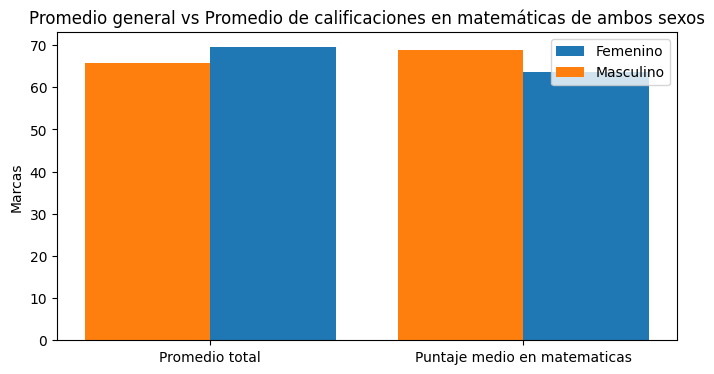

In [29]:
plt.figure(figsize=(8,4))

X = ['Promedio total', 'Puntaje medio en matematicas']

puntaje_femenino = [grupo_genero['promedio'][0], grupo_genero['nota_matematica'][0]]
puntaje_hombre = [grupo_genero['promedio'][1], grupo_genero['nota_matematica'][1]]

X_axis = np.arange(len(X))

plt.bar(X_axis + 0.2, puntaje_femenino, 0.4, label= 'Femenino')
plt.bar(X_axis - 0.2, puntaje_hombre, 0.4, label='Masculino')

plt.xticks(X_axis, X)
plt.ylabel('Marcas')
plt.title('Promedio general vs Promedio de calificaciones en matemáticas de ambos sexos')
plt.legend()
plt.show()

Análisis:
* En promedio, las mujeres obtienen una mejor puntuación general que los hombres.

* Mientras que los hombres obtienen una puntuación más alta en matemáticas

## 4.4.2 Columna de grupo etnico:

* ¿Cómo es la distribución por grupos?

+ ¿Influye la etnia en el rendimiento de los estudiantes?

### ANÁLISIS UNIVARIADO (¿Cómo es la distribución por grupos')

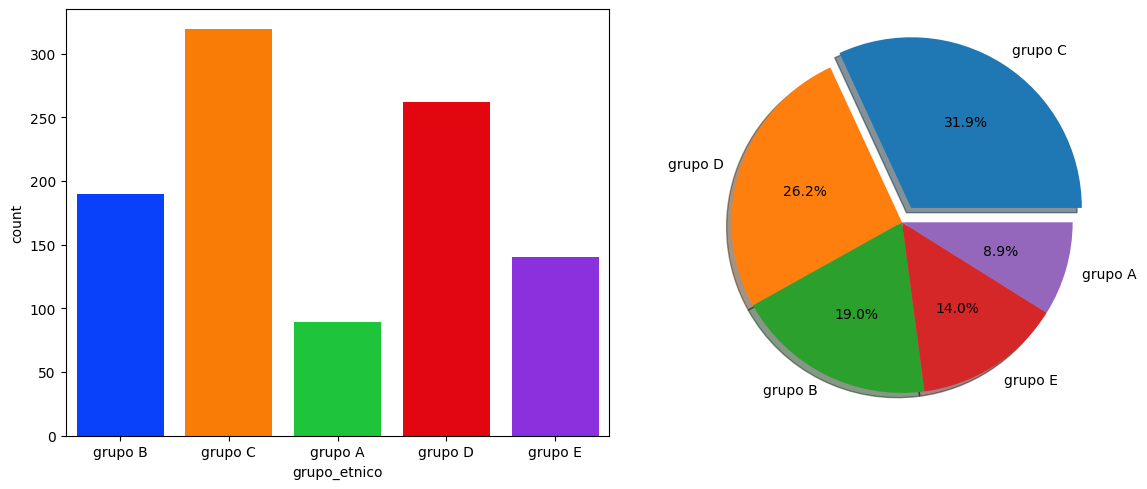

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x= df['grupo_etnico'], data= df, palette='bright', ax=axs[0], saturation=0.95)

for conteiner in axs[0].containers:
    axs[0].bar_label(container, color='black', size=20)

axs[1].pie(
    x= df['grupo_etnico'].value_counts(),
    labels= df['grupo_etnico'].value_counts().index, 
    explode=[0.1,0,0,0,0], autopct='%1.1f%%', 
    shadow=True
)

plt.tight_layout()
plt.show()

Análisis:
* La mayoria de los estudiantes pertenecen al grupo C / grupo D.

* El menor número de estudiantes pertenece al grupo A.

### ANÁLISIS BIVARIADO (¿Tiene la etnia algún impacto en el rendimiento estudiantil?)

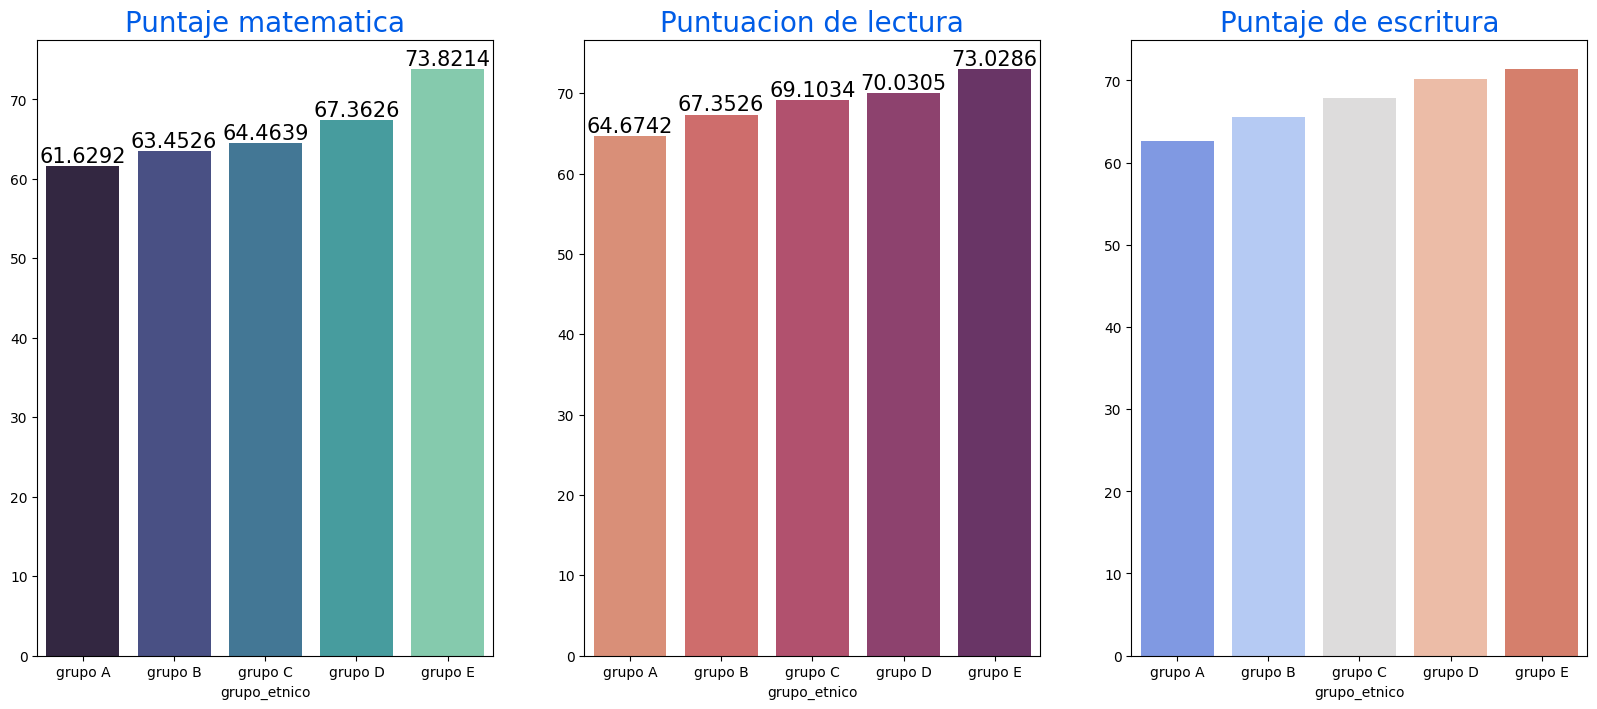

In [31]:
Grupo_data2 = df.groupby('grupo_etnico')
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

sns.barplot(x=Grupo_data2['nota_matematica'].mean().index, y= Grupo_data2['nota_matematica'].mean().values, palette= 'mako', ax=axs[0])
axs[0].set_title('Puntaje matematica', color='#005ce6', size=20)

for container in axs[0].containers:
    axs[0].bar_label(container, color= 'black', size=15)

sns.barplot(x= Grupo_data2['nota_lectura'].mean().index, y=Grupo_data2['nota_lectura'].mean().values, palette= 'flare', ax=axs[1])
axs[1].set_title('Puntuacion de lectura', color= '#005ce6', size= 20)

for container in axs[1].containers:
    axs[1].bar_label(container, color= 'black', size= 15)

sns.barplot(x= Grupo_data2['nota_escritura'].mean().index, y= Grupo_data2['nota_escritura'].mean().values, palette= 'coolwarm', ax=axs[2])
axs[2].set_title('Puntaje de escritura', color= '#005ce6', size= 20)

for container in axs[2].containers:
    axs[2].bar_label(conteiner, color='black', size=15)

Análisis:

* Los estudiantes del grupo E obtuvieron las calificaciones más altas.

* Los estudiantes del grupo A obtuvieron las calificaciones más bajas.

* Los estudiantes de menor nivel socioeconómico tienen un promedio más bajo en todas las asignaturas.

## 4.4.3 COLUMNA SOBRE EL NIVEL EDUCATIVO DE LOS PADRES

* ¿Cuál es el nivel educativo de los padres del estudiante?

* ¿Influye la educación de los padres en el rendimiento académico del estudiante??

### ANÁLISIS UNIVARIADO (¿Cuál es el nivel educativo de los padres del estudiante?)

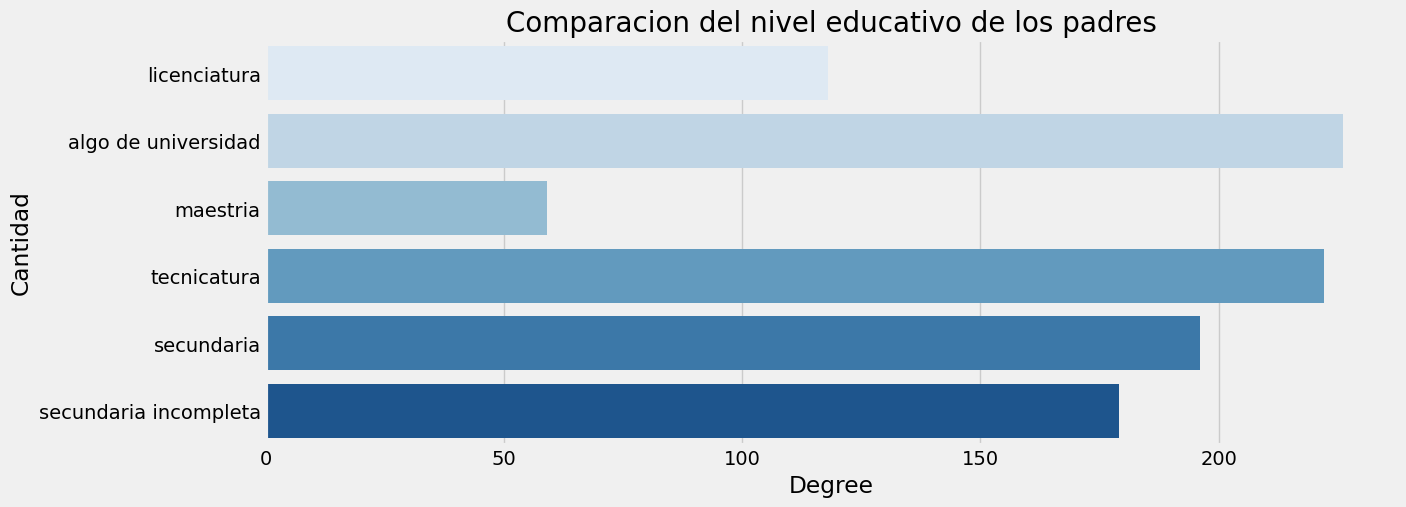

In [32]:
plt.rcParams['figure.figsize'] = (13, 5)
plt.style.use('fivethirtyeight')
sns.countplot(df['nivel_educacion_padres'], palette= 'Blues')
plt.title('Comparacion del nivel educativo de los padres', fontweight= 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('Cantidad')
plt.show()

Análisis:

La mayoria de los padres son estudiantes universitarios.

### ANÁLISIS BIVARIADO (¿Tiene la educación de los padres algún impacto en el rendimiento del estudiante?)

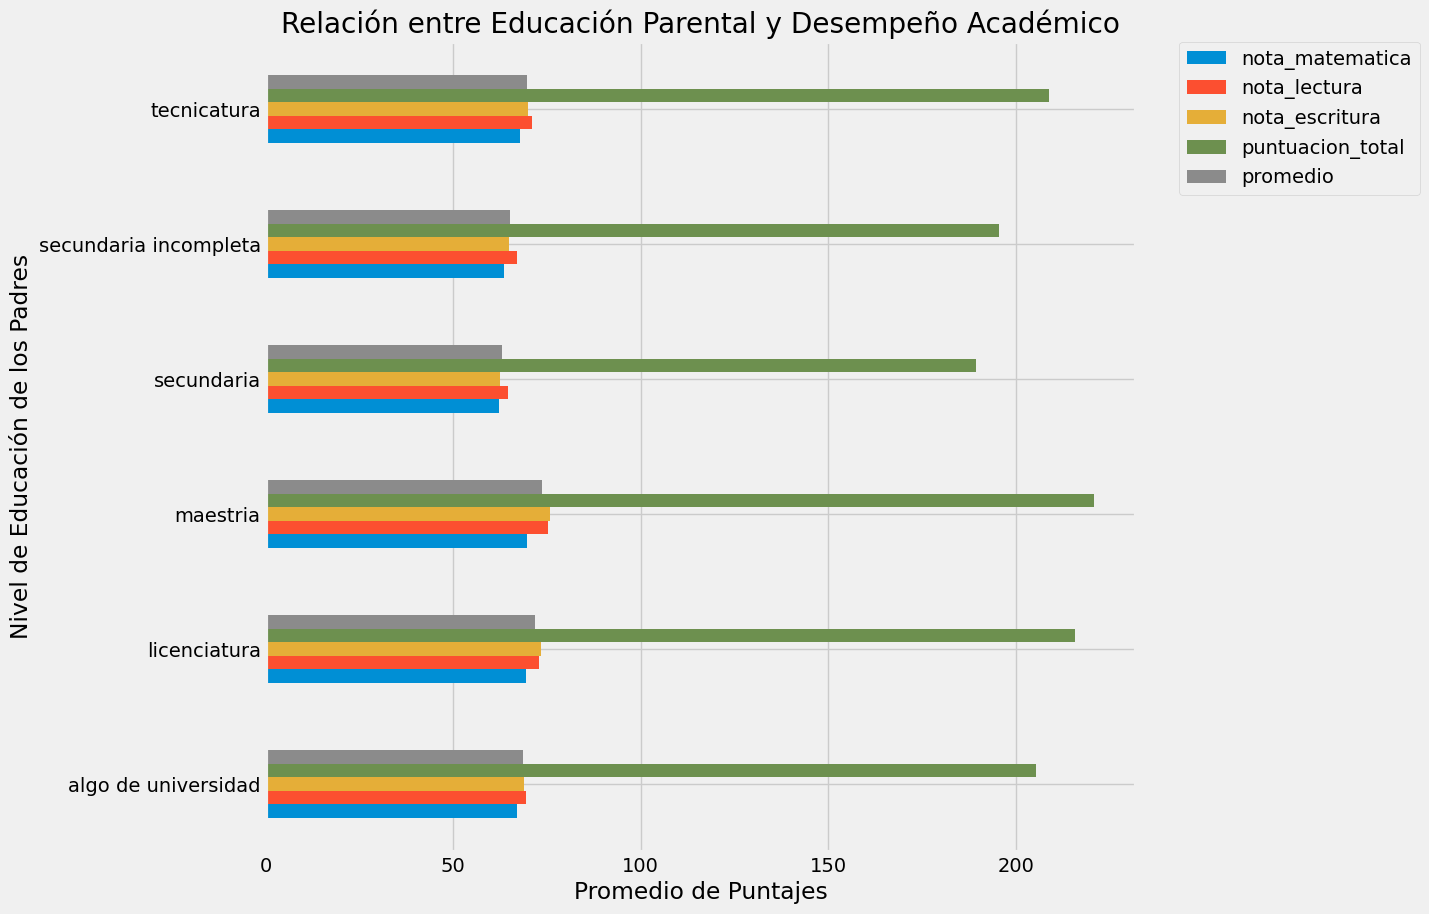

In [33]:
# 1. Agregamos numeric_only=True para evitar el TypeError con columnas de texto
# 2. .agg('mean') es válido, pero .mean(numeric_only=True) es más directo
df.groupby('nivel_educacion_padres').mean(numeric_only=True).plot(kind='barh', figsize=(10, 10))

# Ajustamos la leyenda para que no tape el gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Opcional: Añadir etiquetas para mayor claridad
plt.xlabel('Promedio de Puntajes')
plt.ylabel('Nivel de Educación de los Padres')
plt.title('Relación entre Educación Parental y Desempeño Académico')

plt.show()

Análisis: Las calificaciones de los estudiantes cuyos padres poseen estudios de maestria y licenciatura son más altas que las de los demás.

### 4.4.4 COLUMNA DE ALMUERZO:

* ¿Qué tipo de almuerzo es el más común entre los estudiantes?

* ¿Cual es el efecto del tipo de almuerzo en los resultados de las pruebas?

### ANÄLISIS UNIVARIADO (¿Qué tipo de almuerzo es el más común entre los estudiantes?)

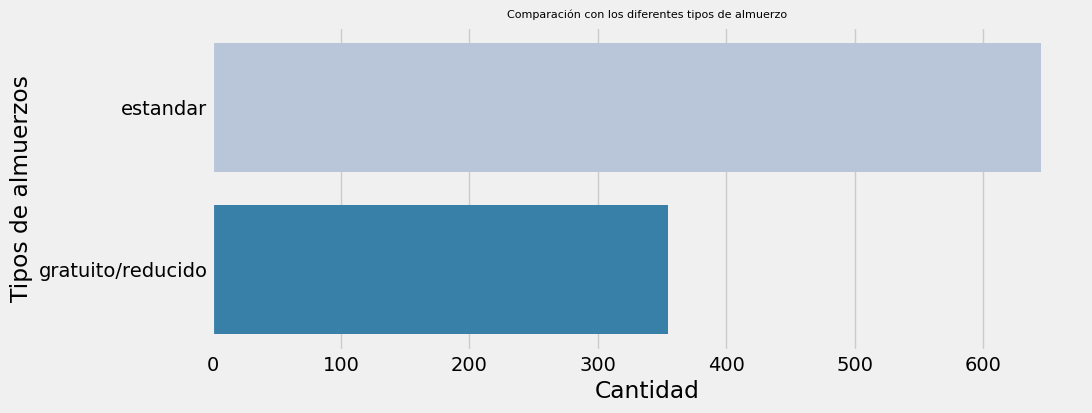

In [34]:
plt.rcParams['figure.figsize'] = (10, 4)

sns.countplot(df['almuerzo'], palette= 'PuBu')
plt.title('Comparación con los diferentes tipos de almuerzo', fontweight = 17, fontsize= 8)
plt.xlabel('Cantidad')
plt.ylabel('Tipos de almuerzos')
plt.show()

Los estudiantes que recibieron el almuerzo estándar recibieron más que un almuerzo gratuito

### ANÁLISIS BIVARIADO (¿Tiene el tipo de almuerzo algún impacto en el rendimiento del estudiante?)

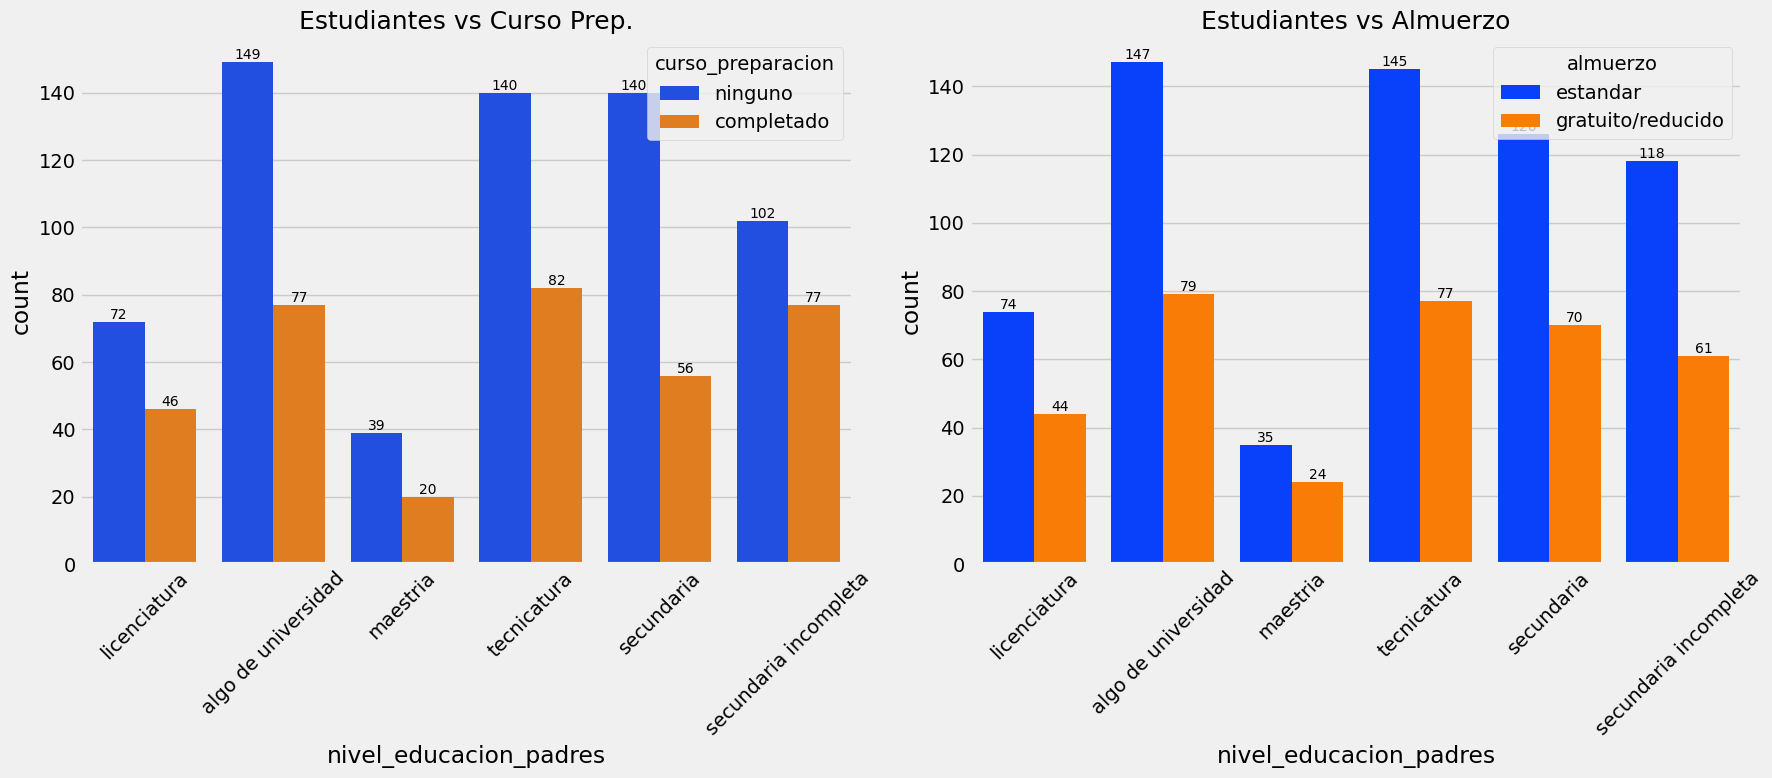

In [35]:
# Aumentamos un poco el ancho (15 o 18) para que respiren los dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# --- PRIMER GRÁFICO ---
sns.countplot(x=df['nivel_educacion_padres'], data=df, palette='bright', hue='curso_preparacion', ax=axs[0])
axs[0].set_title('Estudiantes vs Curso Prep.', color='black', size=18)
# Rotamos las etiquetas del eje X para que no se encimen
axs[0].tick_params(axis='x', labelrotation=45)

for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=10)

# --- SEGUNDO GRÁFICO ---
sns.countplot(x=df['nivel_educacion_padres'], data=df, palette='bright', hue='almuerzo', saturation=0.95, ax=axs[1])
axs[1].set_title('Estudiantes vs Almuerzo', color='black', size=18)
# Rotamos las etiquetas aquí también
axs[1].tick_params(axis='x', labelrotation=45)

for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=10)

# Ajuste automático para que nada se solape
plt.tight_layout()
plt.show()

Los estudiantes que reciben el almuerzo estándar tienden a tener un mejor rendimiento que los que reciben almuerzos gratuito o a precio reducido

## 4.4.5 COLUMNA DEL CURSO DE PREPARACIÓN PARA EXÁMENES:
* ¿Qué tipo de almuerzo es el más común entre los estudiantes?
* ¿Tiene el curso de preparación para exámenes algún impacto en el rendimiento estudiantil?


### ANÁLISIS BIVARIADO ('Tiene el curso de preparación para exámenes algún impacto en el rendimiento estudiantil?)

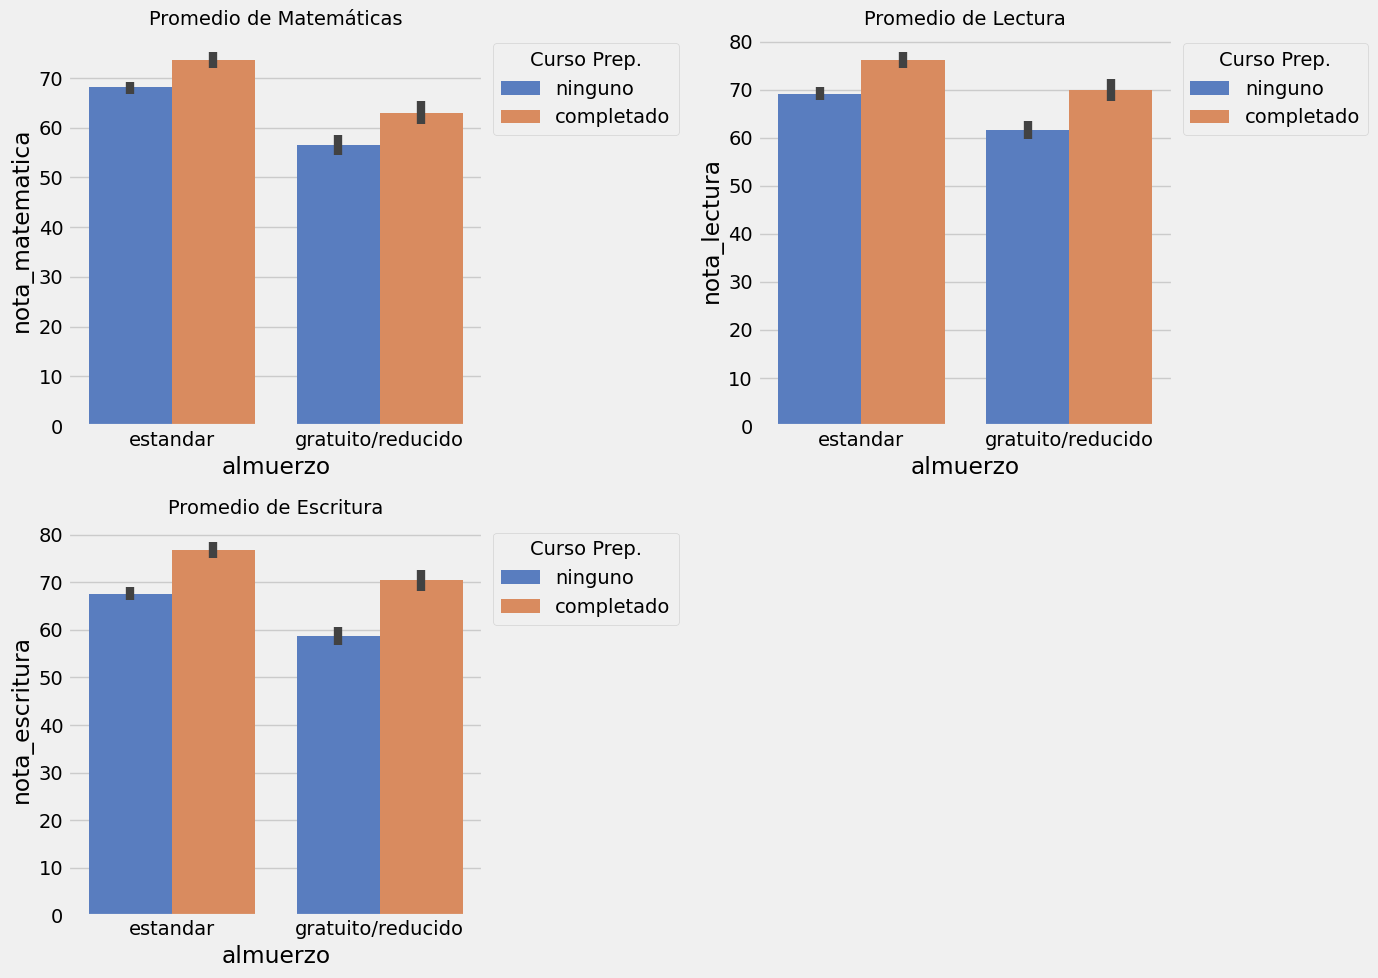

In [36]:
plt.figure(figsize=(14, 10))

# Lista de las notas para iterar y no repetir código
notas = [('nota_matematica', 'Matemáticas'), 
         ('nota_lectura', 'Lectura'), 
         ('nota_escritura', 'Escritura')]

for i, (col, titulo) in enumerate(notas, 1):
    plt.subplot(2, 2, i)
    # Usar el parámetro 'data' es la forma recomendada en Seaborn
    sns.barplot(x='almuerzo', y=col, hue='curso_preparacion', data=df, palette='muted')
    plt.title(f'Promedio de {titulo}', fontsize=14)
    plt.legend(title='Curso Prep.', bbox_to_anchor=(1, 1))

# Ajuste para que los títulos y ejes no se encimen
plt.tight_layout()
plt.show()

Análisis: Los estudiantes que han completado el curso de preparación para el examen obtienen puntuaciones más altas en las tres categorias que aquellos que no lo han realizado.

## 4.4.6 COMPROBACIÓN DE VALORES ATÍPICOS

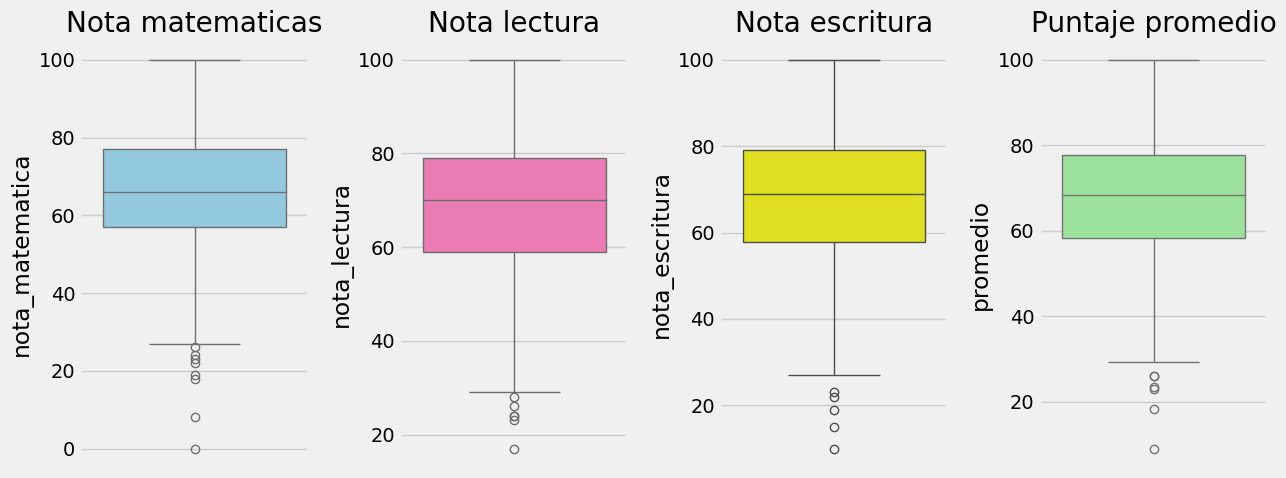

In [37]:
fig, axs = plt.subplots(1, 4, figsize=(13, 5))

sns.boxplot(y=df['nota_matematica'], color= 'skyblue', ax=axs[0])
axs[0].set_title('Nota matematicas')

sns.boxplot(y= df['nota_lectura'], color= 'hotpink', ax=axs[1])
axs[1].set_title('Nota lectura')

sns.boxplot(y= df['nota_escritura'], color= 'yellow', ax=axs[2])
axs[2].set_title('Nota escritura')

sns.boxplot(y= df['promedio'], color= 'lightgreen', ax =axs[3])
axs[3].set_title('Puntaje promedio')

plt.tight_layout()
plt.show()

### 4.4.7 ANÁLISIS MULTIVARIADO MEDIANTE PAIRPLOT

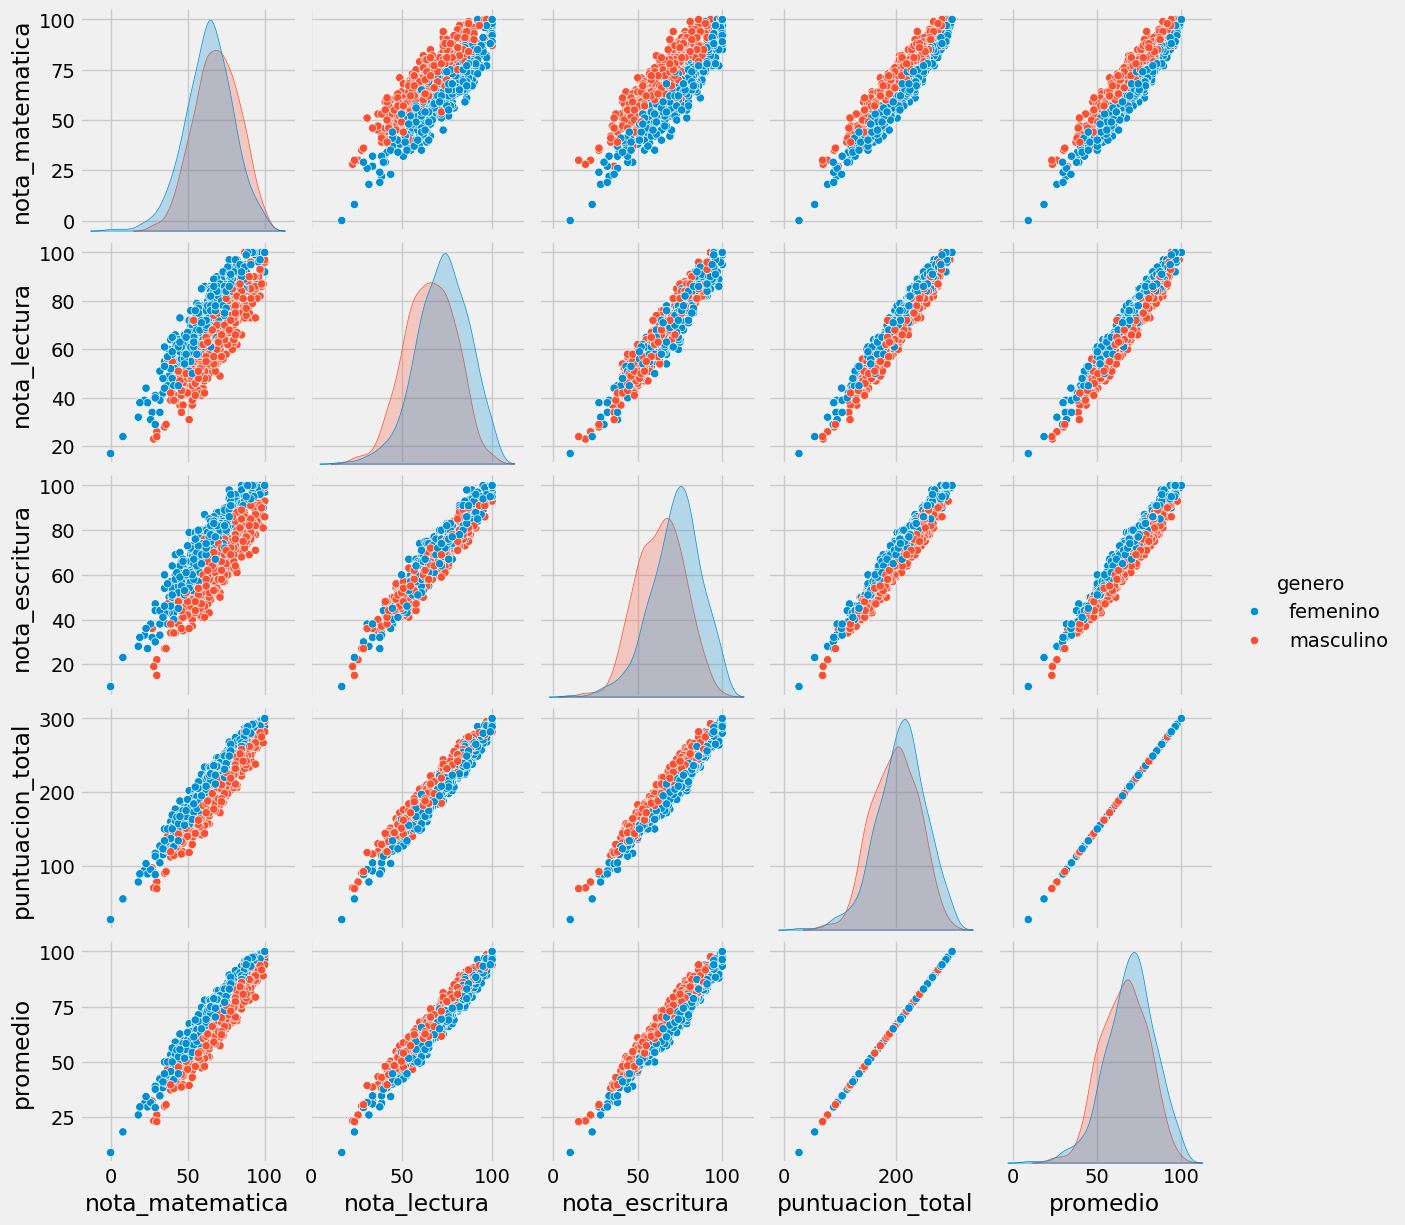

In [38]:
sns.pairplot(df, hue= 'genero')
plt.show()

Conclusiones:

* Del grafico anterior se desprende claramente que todas las puntuaciones aumentan linealmente entre si

## 5. Conculsiones:

* El rendimiento estudiantil está relacionado con el almuerzo, la raza y el nivel educativo de los padres.

* Las mujeres lideran en porcentaje de aprobados y tambien obtienen las mejores clasificaciones.

* El rendimiento estudiantil no esta muy relacionado con los cursos de preparación de exámenes.

* Completar un curso de preparación es beneficioso.